In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

# ── CICIoMT-2024 Final Comparison Table ──────────────────────────────────
results_iomt = {
    'model': ['Random Forest', 'XGBoost', 'MLP', 'BiLSTM', '1D-CNN', 'Logistic Regression'],
    'f1':        [0.9995, 0.9991, 0.9979, 0.9978, 0.9974, 0.9942],
    'auc_roc':   [0.9999, 1.0000, 0.9995, 0.9996, 0.9994, 0.9979],
    'precision': [0.9998, 0.9983, 1.0000, 1.0000, 1.0000, 0.9999],
    'recall':    [0.9991, 0.9999, 0.9958, 0.9957, 0.9948, 0.9885],
    'accuracy':  [0.9989, 0.9983, 0.9959, 0.9958, 0.9949, 0.9887]
}

df_iomt = pd.DataFrame(results_iomt).set_index('model').sort_values('f1', ascending=False)
print("CICIoMT-2024 — Final Model Comparison:")
print(df_iomt.to_string())
df_iomt.to_csv(os.path.join(RESULTS, "ciciomt2024_model_comparison.csv"))
print("\nSaved: ciciomt2024_model_comparison.csv")

# ── Cross-Dataset Comparison Table ───────────────────────────────────────
results_ciciot = {
    'model': ['Random Forest', 'XGBoost', 'MLP', 'BiLSTM', '1D-CNN', 'Logistic Regression'],
    'f1':        [0.9872, 0.9805, 0.9786, 0.9779, 0.9780, 0.9744],
    'auc_roc':   [0.9952, 0.9958, 0.9929, 0.9924, 0.9922, 0.9892],
}

df_ciciot = pd.DataFrame(results_ciciot).set_index('model')

print("\n\nCROSS-DATASET F1 COMPARISON:")
print(f"{'Model':<25} {'CIC-IoT-2023':>15} {'CICIoMT-2024':>15} {'Difference':>12}")
print("-" * 70)
for model in df_ciciot.index:
    f1_iot  = df_ciciot.loc[model, 'f1']
    f1_iomt = df_iomt.loc[model, 'f1']
    diff    = f1_iomt - f1_iot
    print(f"{model:<25} {f1_iot:>15.4f} {f1_iomt:>15.4f} {diff:>+12.4f}")

print("\n\nCROSS-DATASET AUC-ROC COMPARISON:")
print(f"{'Model':<25} {'CIC-IoT-2023':>15} {'CICIoMT-2024':>15} {'Difference':>12}")
print("-" * 70)
for model in df_ciciot.index:
    auc_iot  = df_ciciot.loc[model, 'auc_roc']
    auc_iomt = df_iomt.loc[model, 'auc_roc']
    diff     = auc_iomt - auc_iot
    print(f"{model:<25} {auc_iot:>15.4f} {auc_iomt:>15.4f} {diff:>+12.4f}")

In [ ]:
# ── SHAP Analysis on Random Forest (CICIoMT-2024) ────────────────────────
X_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_X_test.npy"))
feature_names = joblib.load(os.path.join(PROCESSED, "ciciomt2024_feature_names.pkl"))
rf = joblib.load(os.path.join(MODELS, "ciciomt2024_random_forest.pkl"))

X_test_df = pd.DataFrame(X_test, columns=feature_names)

print("Computing SHAP values...")
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_df), 500, replace=False)
X_sample = X_test_df.iloc[sample_idx]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# Fix 3D shape
sv = shap_values
if isinstance(sv, list):
    sv = sv[1]
if sv.ndim == 3:
    sv = sv[:, :, 1]
print(f"SHAP values shape: {sv.shape}")

# Bar chart
shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  plot_type="bar", max_display=10, show=False)
plt.title("SHAP Mean |SHAP Value| — Random Forest CICIoMT-2024 (Top 10)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_shap_bar.png"), dpi=150)
plt.show()
print("Saved: ciciomt2024_shap_bar.png")

# Beeswarm
shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  max_display=10, show=False)
plt.title("SHAP Feature Importance — Random Forest CICIoMT-2024 (Top 10)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_shap_beeswarm.png"), dpi=150)
plt.show()
print("Saved: ciciomt2024_shap_beeswarm.png")

# Top 10
mean_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_shap.to_csv(os.path.join(RESULTS, "ciciomt2024_shap_feature_importance.csv"), index=False)
print("\nTop 10 features:")
print(mean_shap.head(10).to_string())

Computing SHAP values...
SHAP values shape: (500, 38)


C:\Users\CyrilCorp\AppData\Local\Temp\ipykernel_83744\1953337926.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, feature_names=feature_names,


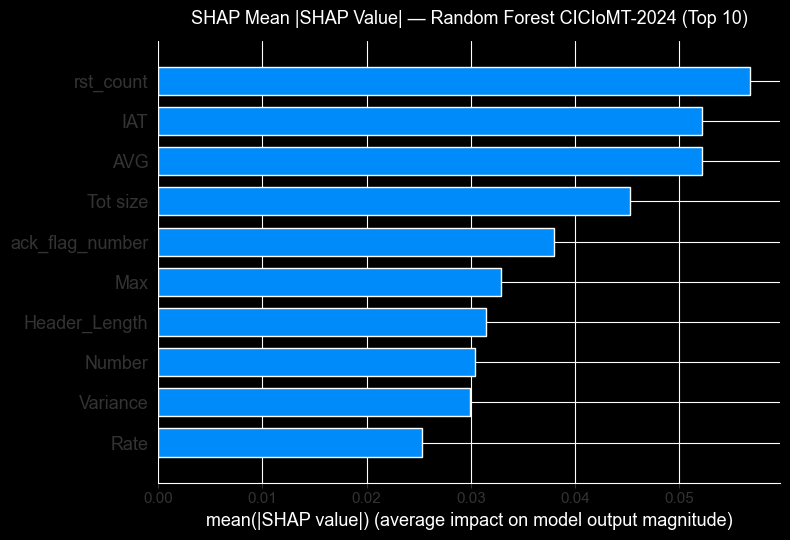

Saved: ciciomt2024_shap_bar.png


C:\Users\CyrilCorp\AppData\Local\Temp\ipykernel_83744\1953337926.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, feature_names=feature_names,


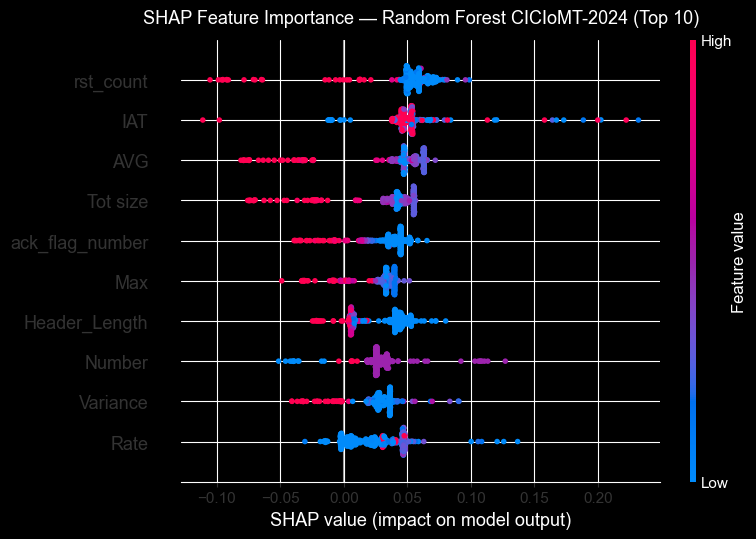

Saved: ciciomt2024_shap_beeswarm.png

Top 10 features:
           feature  mean_abs_shap
0        rst_count       0.056809
1              IAT       0.052204
2              AVG       0.052185
3         Tot size       0.045240
4  ack_flag_number       0.037979
5              Max       0.032897
6    Header_Length       0.031463
7           Number       0.030376
8         Variance       0.029959
9             Rate       0.025336


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 18 SUMMARY — SHAP + Cross-Dataset Comparison
# ══════════════════════════════════════════════════════════════════════════
#
# CICIOMT-2024 FINAL LEADERBOARD:
#   1. Random Forest   F1=0.9995  AUC=0.9999
#   2. XGBoost         F1=0.9991  AUC=1.0000
#   3. MLP             F1=0.9979  AUC=0.9995
#   4. BiLSTM          F1=0.9978  AUC=0.9996
#   5. 1D-CNN          F1=0.9974  AUC=0.9994
#   6. Log. Regression F1=0.9942  AUC=0.9979
#
# SHAP TOP FEATURES — CICIoMT-2024 (Random Forest):
#   1. rst_count        0.0568  ← RST flag resets (connection attacks)
#   2. IAT              0.0522  ← inter-arrival time
#   3. AVG              0.0522  ← avg packet length
#   4. Tot size         0.0452  ← total packet length
#   5. ack_flag_number  0.0380  ← ACK flag proportion
#
# CROSS-DATASET KEY FINDINGS:
#   All 6 models improve on CICIoMT-2024 vs CIC-IoT-2023 (~+0.019 F1)
#   Random Forest leads on F1 on both datasets
#   XGBoost leads on AUC-ROC on both datasets
#   All 3 DL models achieve perfect precision (1.0000) on CICIoMT-2024
#   Classical ML consistently outperforms DL on F1 across both datasets
#
# TOP FEATURE COMPARISON:
#   CIC-IoT-2023:  Number (packet count) — volumetric flooding
#   CICIoMT-2024:  rst_count (RST flags) — connection-based attacks
#   Both are network-layer attack indicators but different signatures
#
# CONCLUSION:
#   Model rankings are consistent across datasets — Random Forest wins
#   F1 on both, confirming generalizability of classical ML superiority
#   over deep learning on window-aggregated tabular IoT features.
#   CICIoMT-2024 is more separable (~+0.019 F1 improvement across all
#   models) suggesting medical IoT attacks have more distinct network
#   signatures than general IoT attacks.
# ══════════════════════════════════════════════════════════════════════════

Computing SHAP values...
SHAP values shape: (500, 38)


C:\Users\CyrilCorp\AppData\Local\Temp\ipykernel_83744\1953337926.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, feature_names=feature_names,


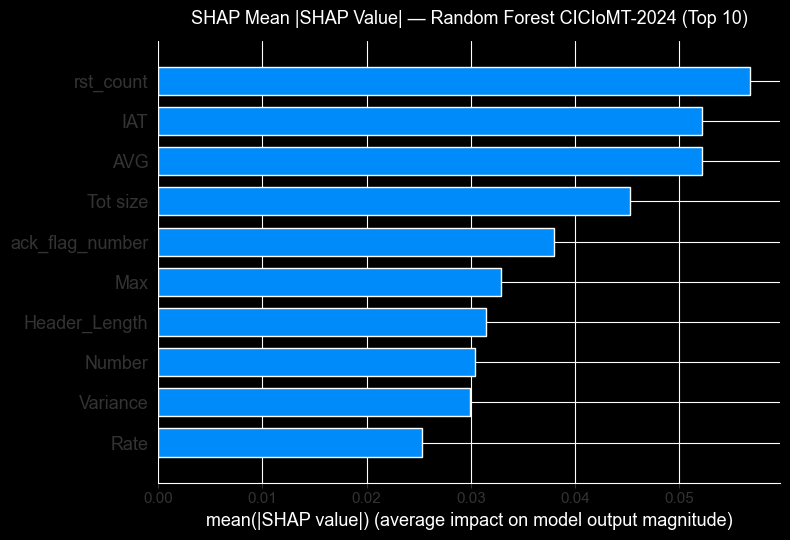

Saved: ciciomt2024_shap_bar.png


C:\Users\CyrilCorp\AppData\Local\Temp\ipykernel_83744\1953337926.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, feature_names=feature_names,


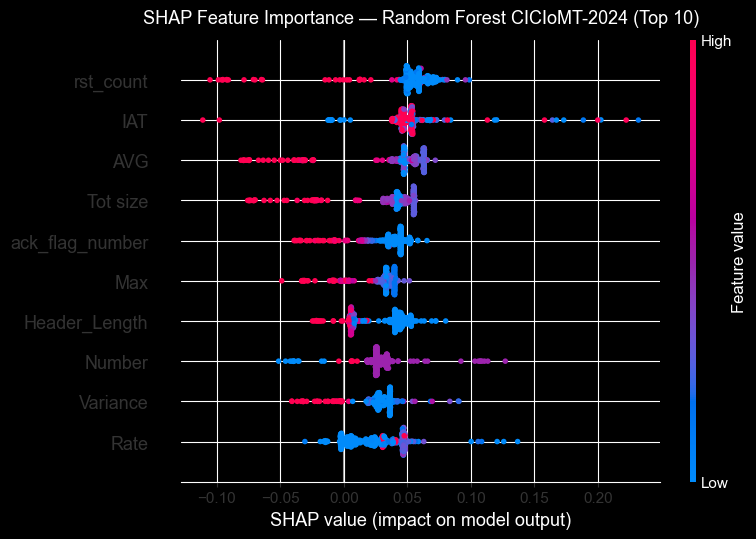

Saved: ciciomt2024_shap_beeswarm.png

Top 10 features:
           feature  mean_abs_shap
0        rst_count       0.056809
1              IAT       0.052204
2              AVG       0.052185
3         Tot size       0.045240
4  ack_flag_number       0.037979
5              Max       0.032897
6    Header_Length       0.031463
7           Number       0.030376
8         Variance       0.029959
9             Rate       0.025336


In [2]:
# ── SHAP Analysis on Random Forest (CICIoMT-2024) ────────────────────────
X_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_X_test.npy"))
feature_names = joblib.load(os.path.join(PROCESSED, "ciciomt2024_feature_names.pkl"))
rf = joblib.load(os.path.join(MODELS, "ciciomt2024_random_forest.pkl"))

X_test_df = pd.DataFrame(X_test, columns=feature_names)

print("Computing SHAP values...")
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_df), 500, replace=False)
X_sample = X_test_df.iloc[sample_idx]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# Fix 3D shape
sv = shap_values
if isinstance(sv, list):
    sv = sv[1]
if sv.ndim == 3:
    sv = sv[:, :, 1]
print(f"SHAP values shape: {sv.shape}")

# Bar chart
shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  plot_type="bar", max_display=10, show=False)
plt.title("SHAP Mean |SHAP Value| — Random Forest CICIoMT-2024 (Top 10)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_shap_bar.png"), dpi=150)
plt.show()
print("Saved: ciciomt2024_shap_bar.png")

# Beeswarm
shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  max_display=10, show=False)
plt.title("SHAP Feature Importance — Random Forest CICIoMT-2024 (Top 10)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_shap_beeswarm.png"), dpi=150)
plt.show()
print("Saved: ciciomt2024_shap_beeswarm.png")

# Top 10
mean_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_shap.to_csv(os.path.join(RESULTS, "ciciomt2024_shap_feature_importance.csv"), index=False)
print("\nTop 10 features:")
print(mean_shap.head(10).to_string())